# Hand Gesture Classification Using MediaPipe Landmarks (HaGRID Dataset)

We follow the full ML pipeline: **Data Loading → Visualization → Preprocessing → Model Training → Evaluation → Conclusion**.

## 0. Import Dependencies

In [1]:
import os
import warnings
import urllib.request
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import joblib
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import drawing_utils as mp_drawing
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline

import mlflow
from mlflow_utils import run_mlflow_tracking

warnings.filterwarnings('ignore')

---
## 1. Data Loading

The CSV contains 21 hand landmarks per sample (x, y, z coordinates each) → **63 features** + 1 label column.

In [2]:
CSV_PATH = 'hand_landmarks_data.csv'

df = pd.read_csv(CSV_PATH)
print('=== Dataset Info ===')
print(f'\nDataset shape : {df.shape}')
print(f'\nColumns       : {list(df.columns)}')
df.head(5)

=== Dataset Info ===

Dataset shape : (25675, 64)

Columns       : ['x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4', 'x5', 'y5', 'z5', 'x6', 'y6', 'z6', 'x7', 'y7', 'z7', 'x8', 'y8', 'z8', 'x9', 'y9', 'z9', 'x10', 'y10', 'z10', 'x11', 'y11', 'z11', 'x12', 'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14', 'x15', 'y15', 'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18', 'y18', 'z18', 'x19', 'y19', 'z19', 'x20', 'y20', 'z20', 'x21', 'y21', 'z21', 'label']


,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [3]:
print('=== Data Types ===')
print(df.dtypes.value_counts())
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\n=== Class Distribution ===')
print(df['label'].value_counts())

=== Data Types ===
float64    63
object      1
Name: count, dtype: int64

Missing values: 0

=== Class Distribution ===
label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64


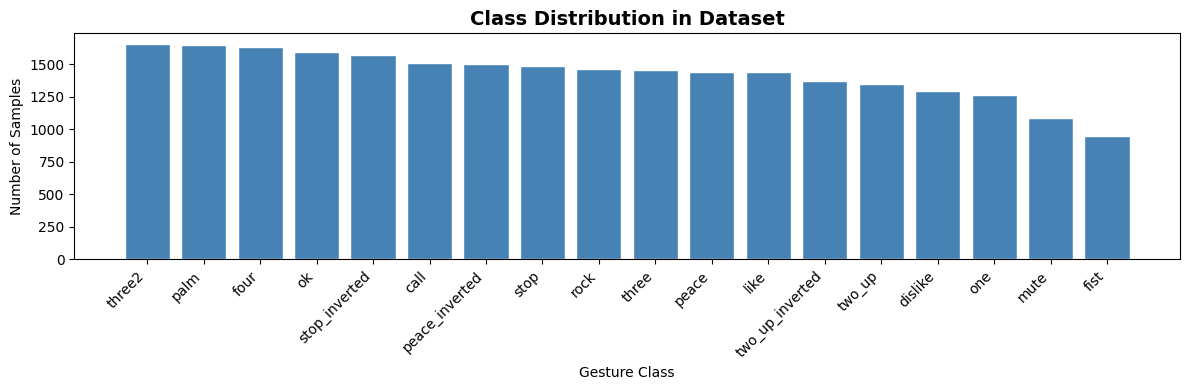

In [4]:
fig_class_dist, ax = plt.subplots(figsize=(12, 4))
counts = df['label'].value_counts()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Gesture Class')
ax.set_ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 2. Data Visualization

We plot the raw hand skeleton (21 keypoints connected along finger chains) for a few sample gestures.

In [5]:
CONNECTIONS = [
    # Palm
    (0, 1), (1, 2), (2, 3), (3, 4),
    # Index
    (0, 5), (5, 6), (6, 7), (7, 8),
    # Middle
    (0, 9), (9, 10), (10, 11), (11, 12),
    # Ring
    (0, 13), (13, 14), (14, 15), (15, 16),
    # Pinky
    (0, 17), (17, 18), (18, 19), (19, 20),
    # Knuckle connections
    (5, 9), (9, 13), (13, 17)
]

def plot_hand(ax, row, title=''):
    """Plot hand skeleton from a DataFrame row (raw coordinates)."""
    xs = [row[f'x{i+1}'] for i in range(21)]
    ys = [row[f'y{i+1}'] for i in range(21)]
    for s, e in CONNECTIONS:
        ax.plot([xs[s], xs[e]], [ys[s], ys[e]], 'g-', linewidth=1.5)
    ax.scatter(xs, ys, c='red', s=30, zorder=5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.axis('off')

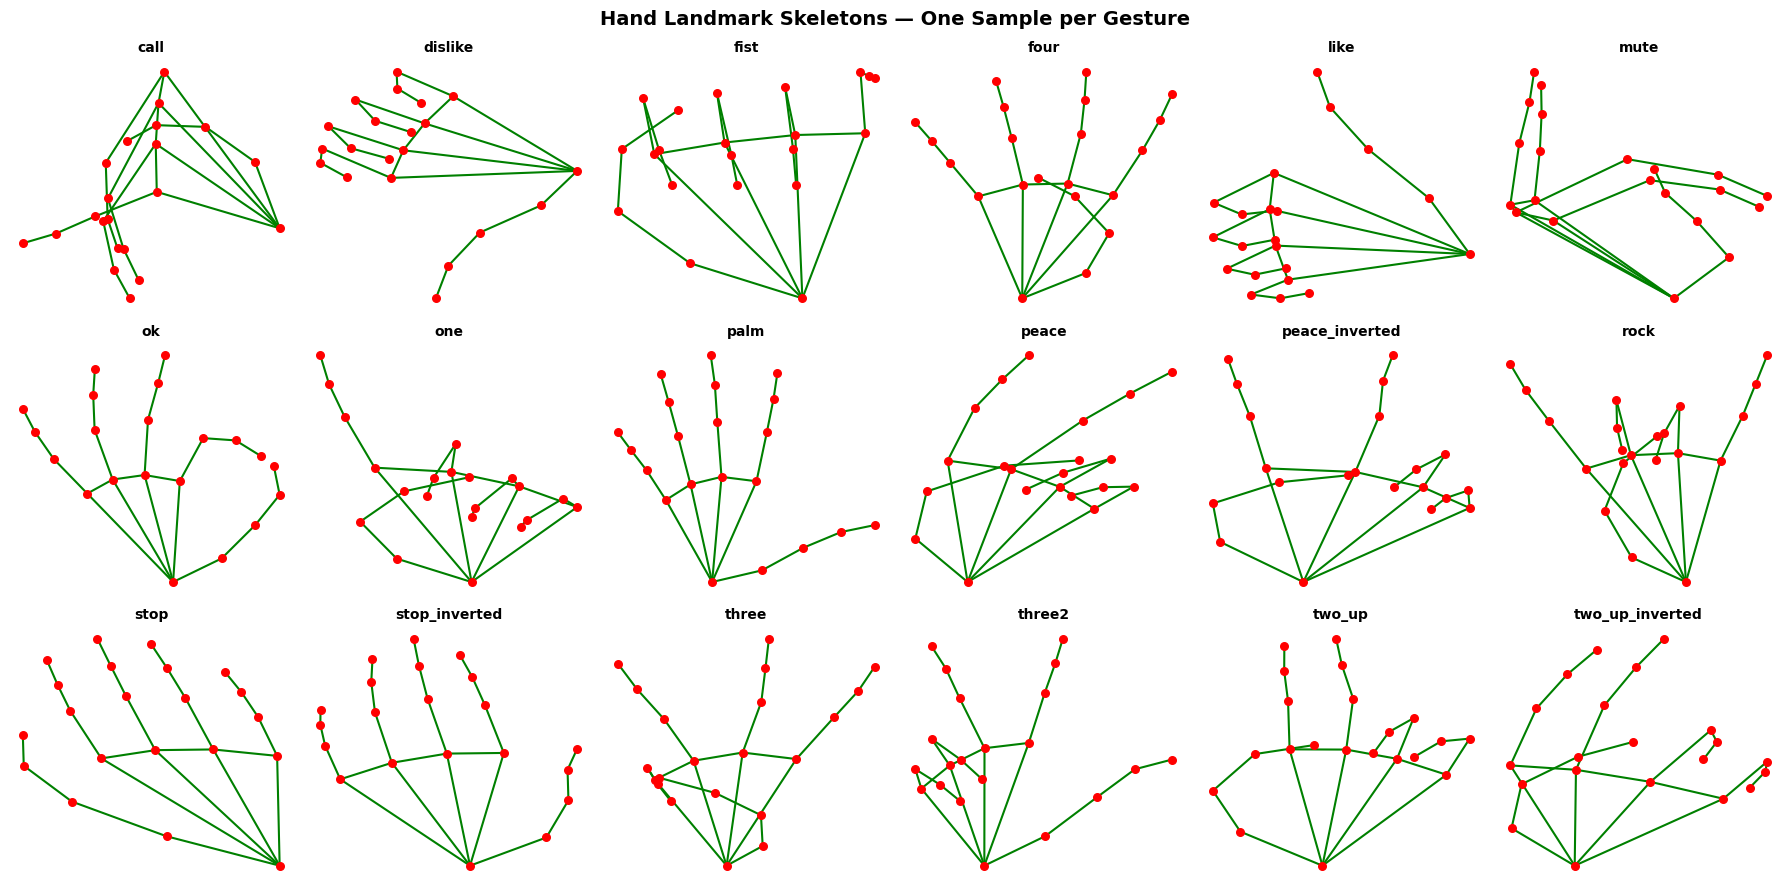

In [6]:
classes = df['label'].unique()
n_classes = len(classes)
ncols = 6
nrows = int(np.ceil(n_classes / ncols))

fig_raw_skeletons, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for idx, cls in enumerate(sorted(classes)):
    sample = df[df['label'] == cls].iloc[0]
    plot_hand(axes[idx], sample, title=cls)

fig_raw_skeletons.suptitle('Hand Landmark Skeletons — One Sample per Gesture', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

### 3.1 Normalization

1. Recenter `(x, y)` so the **wrist** (landmark 0, columns `x1, y1`) is the origin.
2. Divide all `(x, y)` by the distance to the **middle-finger tip** (landmark 12, columns `x13, y13`) so hands are scale-invariant.

In [7]:
def normalize_landmarks(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize hand landmarks: recenter to wrist, scale by mid-finger tip distance."""
    df_norm = df.copy()

    wrist_x = df_norm['x1'].values
    wrist_y = df_norm['y1'].values

    for i in range(1, 22):
        df_norm[f'x{i}'] = df_norm[f'x{i}'] - wrist_x
        df_norm[f'y{i}'] = df_norm[f'y{i}'] - wrist_y

    mid_x = df_norm['x13'].values
    mid_y = df_norm['y13'].values
    scale = np.sqrt(mid_x**2 + mid_y**2)
    scale = np.where(scale == 0, 1e-6, scale)

    for i in range(1, 22):
        df_norm[f'x{i}'] = df_norm[f'x{i}'] / scale
        df_norm[f'y{i}'] = df_norm[f'y{i}'] / scale

    return df_norm


df_norm = normalize_landmarks(df)
print('Normalization complete.')
print('Sample normalized wrist :', df_norm[['x1','y1']].iloc[0].values)
print('Sample normalized mid-finger :', np.sqrt(df_norm['x13'].iloc[0]**2 + df_norm['y13'].iloc[0]**2))

Normalization complete.
Sample normalized wrist : [0. 0.]
Sample normalized mid-finger : 1.0


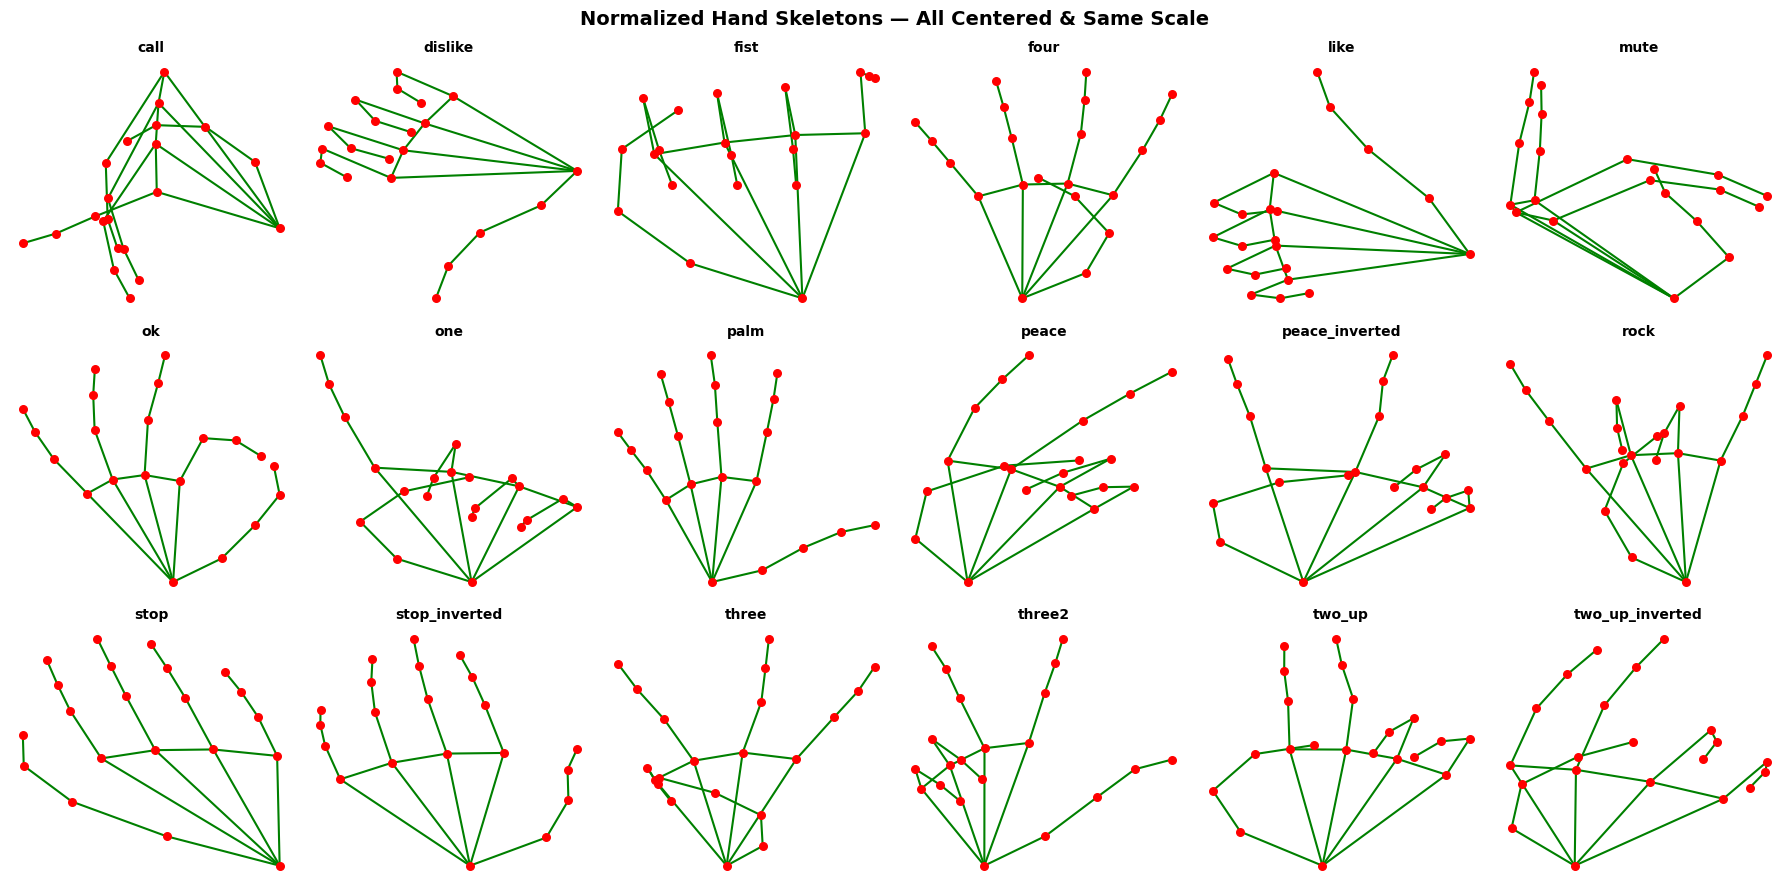

In [8]:
def plot_hand_norm(ax, row, title=''):
    xs = [row[f'x{i+1}'] for i in range(21)]
    ys = [row[f'y{i+1}'] for i in range(21)]
    for s, e in CONNECTIONS:
        ax.plot([xs[s], xs[e]], [ys[s], ys[e]], 'g-', linewidth=1.5)
    ax.scatter(xs, ys, c='red', s=30, zorder=5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.axis('off')

fig_norm_skeletons, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for idx, cls in enumerate(sorted(classes)):
    sample = df_norm[df_norm['label'] == cls].iloc[0]
    plot_hand_norm(axes[idx], sample, title=cls)


fig_norm_skeletons.suptitle('Normalized Hand Skeletons — All Centered & Same Scale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Handle Missing Values & Prepare Features

In [9]:
print('Missing values in normalized data:', df_norm.isnull().sum().sum())

df_norm.dropna(inplace=True)
print(f'Dataset size after dropping NaNs: {df_norm.shape}')

Missing values in normalized data: 0
Dataset size after dropping NaNs: (25675, 64)


In [10]:
feature_cols = [c for c in df_norm.columns if c != 'label']
X = df_norm[feature_cols].values
y_raw = df_norm['label'].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
print('Classes:', le.classes_)
print('Feature matrix shape:', X.shape)

for i, cls in enumerate(le.classes_):
    print(f'{i}: {cls}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Classes: ['call' 'dislike' 'fist' 'four' 'like' 'mute' 'ok' 'one' 'palm' 'peace'
 'peace_inverted' 'rock' 'stop' 'stop_inverted' 'three' 'three2' 'two_up'
 'two_up_inverted']
Feature matrix shape: (25675, 63)
0: call
1: dislike
2: fist
3: four
4: like
5: mute
6: ok
7: one
8: palm
9: peace
10: peace_inverted
11: rock
12: stop
13: stop_inverted
14: three
15: three2
16: two_up
17: two_up_inverted
Train: (20540, 63) | Test: (5135, 63)


---
## 4. Model Training

We train and compare **4 classifiers**:
| # | Model | Notes |
|---|-------|-------|
| 1 | Random Forest | Ensemble of decision trees |
| 2 | Support Vector Machine (RBF kernel) | Effective in high-dim spaces |
| 3 | K-Nearest Neighbours | Simple distance-based |
| 4 | Gradient Boosting | Sequential boosting |

All models use `StandardScaler` inside a `Pipeline` to ensure fair comparison.

In [11]:
models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'KNN (k=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
    # 'Gradient Boosting': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('clf',    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
    # ]),
}

results        = {}
trained_models = {}

for name, pipe in models.items():
    print(f'Training {name}...', end=' ')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name]        = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    trained_models[name] = pipe
    print(f'done  |  Acc={acc:.4f}  F1={f1:.4f}')

print('\nAll models trained.')

Training Random Forest... done  |  Acc=0.9792  F1=0.9792
Training SVM (RBF)... done  |  Acc=0.9698  F1=0.9699
Training KNN (k=5)... done  |  Acc=0.9365  F1=0.9366

All models trained.


In [12]:
run_ids = run_mlflow_tracking(
    models=models,
    results=results,
    trained_models=trained_models,
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_norm=df_norm,
    label_classes=list(le.classes_),
)
print("MLflow tracking complete. Launch UI with: uv run mlflow ui")
for name, rid in run_ids.items():
    print(f"  {name}: {rid}")

2026/02/23 23:59:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/23 23:59:47 INFO mlflow.store.db.utils: Updating database tables
2026/02/23 23:59:50 INFO mlflow.tracking.fluent: Experiment with name 'hand-gesture-classification' does not exist. Creating a new experiment.
2026/02/23 23:59:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/23 23:59:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/23 23:59:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/02/

  Logged Random Forest: 4e785fbf78e348059634d092a870a42c


2026/02/23 23:59:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/02/23 23:59:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/23 23:59:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Logged SVM (RBF): 6aa4190d107f40eabf6294cb01346632


2026/02/23 23:59:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  Logged KNN (k=5): 422103baedff46ca98506eb06f4e8731
MLflow tracking complete. Launch UI with: uv run mlflow ui
  Random Forest: 4e785fbf78e348059634d092a870a42c
  SVM (RBF): 6aa4190d107f40eabf6294cb01346632
  KNN (k=5): 422103baedff46ca98506eb06f4e8731


---
## 5. Evaluation

### 5.1 Summary Table

In [13]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)
results_df = results_df.map(lambda v: f'{v:.4f}')
print('=== Model Comparison (Test Set) ===')
display(results_df)

=== Model Comparison (Test Set) ===


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.9792,0.9794,0.9792,0.9792
SVM (RBF),0.9698,0.9703,0.9698,0.9699
KNN (k=5),0.9365,0.9371,0.9365,0.9366


### 5.2 Metric Bar Charts

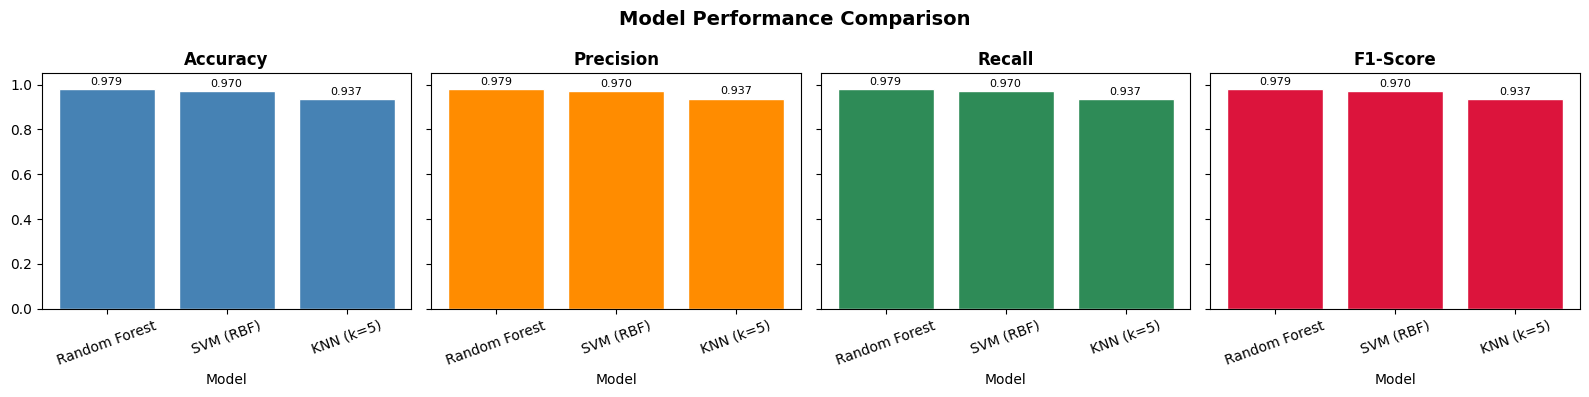

In [14]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
res_float = pd.DataFrame(results).T[metrics].astype(float)

fig_metrics, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(res_float.index, res_float[metric], color=color, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

fig_metrics.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Best Model — Classification Report

In [15]:
best_model_name = res_float['F1-Score'].idxmax()
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f'Best Model: {best_model_name}')
print('='*60)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Best Model: Random Forest
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       301
        dislike       1.00      1.00      1.00       259
           fist       0.99      0.99      0.99       189
           four       0.98      0.99      0.98       327
           like       0.99      0.99      0.99       287
           mute       0.96      0.97      0.97       217
             ok       0.99      0.99      0.99       318
            one       0.94      0.97      0.96       253
           palm       0.99      0.98      0.98       330
          peace       0.98      0.95      0.96       288
 peace_inverted       0.98      0.97      0.98       299
           rock       0.99      0.98      0.99       292
           stop       0.94      0.97      0.96       296
  stop_inverted       0.98      0.98      0.98       314
          three       0.99      0.97      0.98       291
         three2       0.99      0.99      0.99       331
    

### 5.4 Confusion Matrix — Best Model

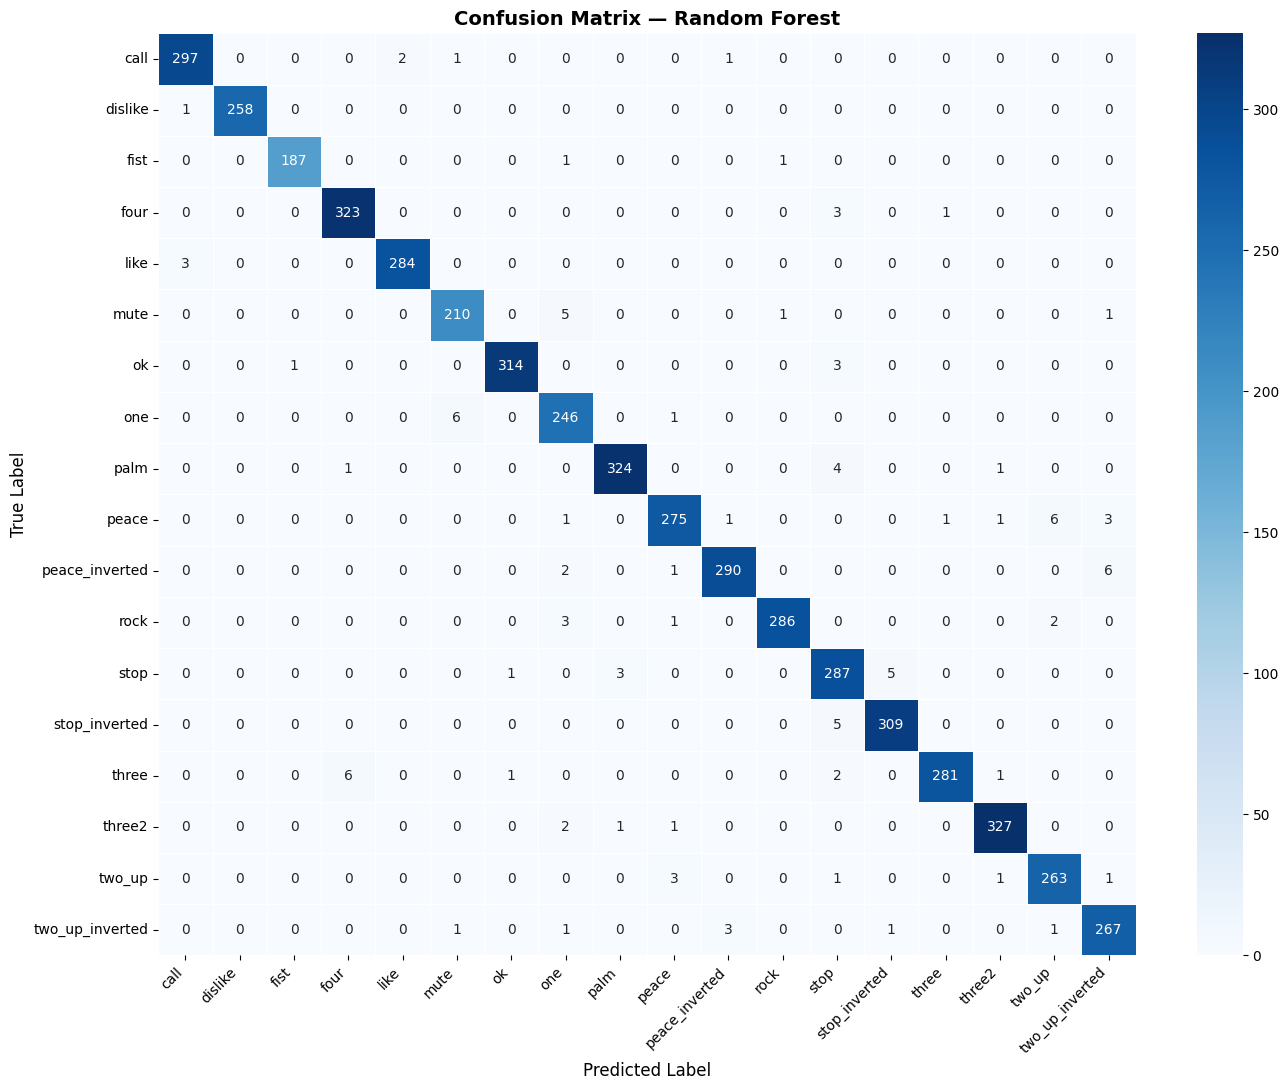

In [16]:
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=ax, linewidths=0.4
)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.5 Feature Importance (Random Forest)

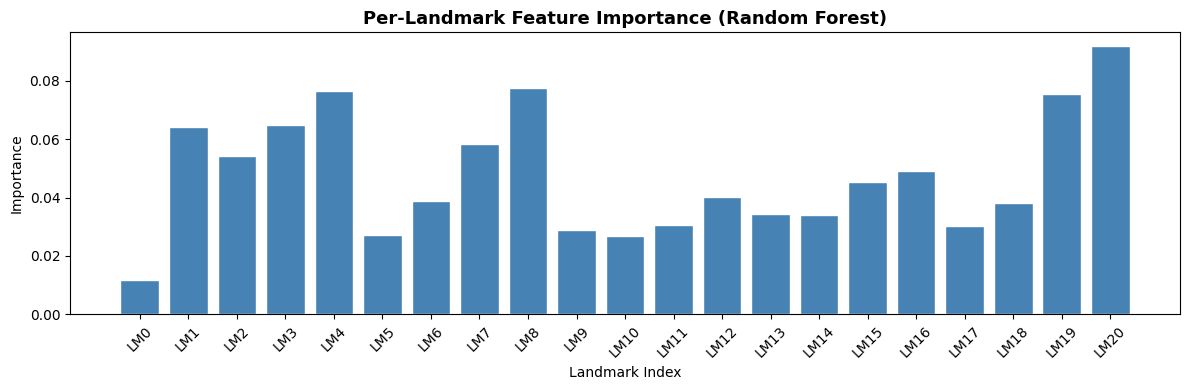

In [17]:
rf_pipe = trained_models['Random Forest']
importances = rf_pipe.named_steps['clf'].feature_importances_

landmark_imp = []
for i in range(21):
    imp = importances[i*3] + importances[i*3+1] + importances[i*3+2]
    landmark_imp.append(imp)

fig_feat_imp, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(21), landmark_imp, color='steelblue', edgecolor='white')
ax.set_xticks(range(21))
ax.set_xticklabels([f'LM{i}' for i in range(21)], rotation=45)
ax.set_title('Per-Landmark Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Landmark Index')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

---
## 6. Save Best Model

In [18]:
joblib.dump(best_model, 'best_gesture_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print(f'Saved: best_gesture_model.pkl  ({best_model_name})')
print('Saved: label_encoder.pkl')

Saved: best_gesture_model.pkl  (Random Forest)
Saved: label_encoder.pkl


---
## 7. Video Inference with MediaPipe

Video Inference Pipeline:
1. Detect hand landmarks with MediaPipe.
2. Apply the same normalization used during training.
3. Predict gesture class with the best model.
4. Smooth predictions with a sliding-window mode to stabilize output to avoid false predictions.
5. Write an annotated output video.

---
### 7.1 Real-Time Webcam Inference

In [19]:
MODEL_PATH = 'hand_landmarker.task'
MODEL_URL  = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print('Downloading hand_landmarker.task...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print('Downloaded.')

model_inf = joblib.load('best_gesture_model.pkl')
le_inf    = joblib.load('label_encoder.pkl')

HAND_CONNECTIONS = mp_vision.HandLandmarksConnections.HAND_CONNECTIONS
DRAW_SPEC_LM     = mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=4)
DRAW_SPEC_CONN   = mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2)

def normalize_landmarks_array(landmarks):
    coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])
    coords[:, 0] -= coords[0, 0]
    coords[:, 1] -= coords[0, 1]
    scale = np.sqrt(coords[12, 0]**2 + coords[12, 1]**2)
    if scale > 0:
        coords[:, 0] /= scale
        coords[:, 1] /= scale
    return coords.flatten()

base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = mp_vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.8,
    min_hand_presence_confidence=0.5,
)

WINDOW_SIZE = 10
window = deque(maxlen=WINDOW_SIZE)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError('Could not open webcam. Check that a camera is connected.')

print('Webcam open. Press Q in the video window to quit.')

with mp_vision.HandLandmarker.create_from_options(options) as landmarker:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result   = landmarker.detect(mp_image)

        label_text = 'No hand detected'
        box_color  = (60, 60, 60)

        if result.hand_landmarks:
            landmarks = result.hand_landmarks[0]

            mp_drawing.draw_landmarks(
                frame, landmarks, HAND_CONNECTIONS,
                landmark_drawing_spec=DRAW_SPEC_LM,
                connection_drawing_spec=DRAW_SPEC_CONN
            )

            features   = normalize_landmarks_array(landmarks).reshape(1, -1)
            pred_idx   = model_inf.predict(features)[0]
            window.append(pred_idx)
            smooth_idx = int(stats.mode(list(window), keepdims=True).mode[0])
            label_text = le_inf.inverse_transform([smooth_idx])[0].upper()
            box_color  = (0, 180, 0)

        h, w = frame.shape[:2]
        cv2.rectangle(frame, (0, 0), (w, 55), (0, 0, 0), -1)
        cv2.putText(frame, f'Gesture: {label_text}', (10, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, box_color, 2, cv2.LINE_AA)
        cv2.putText(frame, 'Press Q to quit', (w - 200, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180, 180, 180), 1, cv2.LINE_AA)

        cv2.imshow('Hand Gesture Recognition', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()
print('Camera closed.')


Webcam open. Press Q in the video window to quit.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1771883997.234182  228628 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771883997.243316  228627 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771883998.165508  228628 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
QFontDatabase: Cannot find font directory /home/omargamalelkady/projects/Hand_Gesture/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/omargamalelkady/projects/Hand_Gesture/.venv/lib/python3.11/site-pac

Camera closed.


---
## 8. Conclusion

### Summary of Results

In [20]:
res_float_sorted = res_float.sort_values('F1-Score', ascending=False)

print('=' * 60)
print('         HAND GESTURE CLASSIFICATION — FINAL RESULTS')
print('=' * 60)
print(f'  Dataset      : HaGRID (MediaPipe landmarks)')
print(f'  Samples      : {len(df_norm)}')
print(f'  Classes      : {len(le.classes_)} gestures')
print(f'  Features     : {X.shape[1]} (21 landmarks * 3 coords)')
print(f'  Train/Test   : 80% / 20%')
print(f'  Normalization: Wrist-centered, mid-finger-tip scaled')
print('=' * 60)
print(res_float_sorted.to_string())
print('=' * 60)
print(f'\n  Best Model   : {best_model_name}')
print(f'  F1-Score     : {res_float.loc[best_model_name, "F1-Score"]:.4f}')
print(f'  Accuracy     : {res_float.loc[best_model_name, "Accuracy"]:.4f}')
print('=' * 60)

         HAND GESTURE CLASSIFICATION — FINAL RESULTS
  Dataset      : HaGRID (MediaPipe landmarks)
  Samples      : 25675
  Classes      : 18 gestures
  Features     : 63 (21 landmarks * 3 coords)
  Train/Test   : 80% / 20%
  Normalization: Wrist-centered, mid-finger-tip scaled
               Accuracy  Precision    Recall  F1-Score
Random Forest  0.979163   0.979361  0.979163  0.979208
SVM (RBF)      0.969815   0.970271  0.969815  0.969870
KNN (k=5)      0.936514   0.937148  0.936514  0.936592

  Best Model   : Random Forest
  F1-Score     : 0.9792
  Accuracy     : 0.9792
